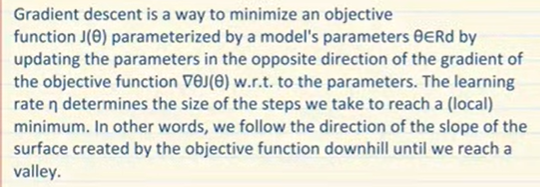

J(theta) --> loss function

### Types

1. **Batch Gradient Descent (The Perfectionist)**
Also known as "Full Batch." In this method, the model looks at your entire dataset before it takes a single step.

How it works: It calculates the error for Image 1, Image 2... all the way to Image 10,000. It averages all 10,000 errors together into a single Cost, calculates one perfect gradient, and takes one step.

The Path: Extremely smooth and direct. The hiker has a perfect compass pointing straight to the bottom of the valley.

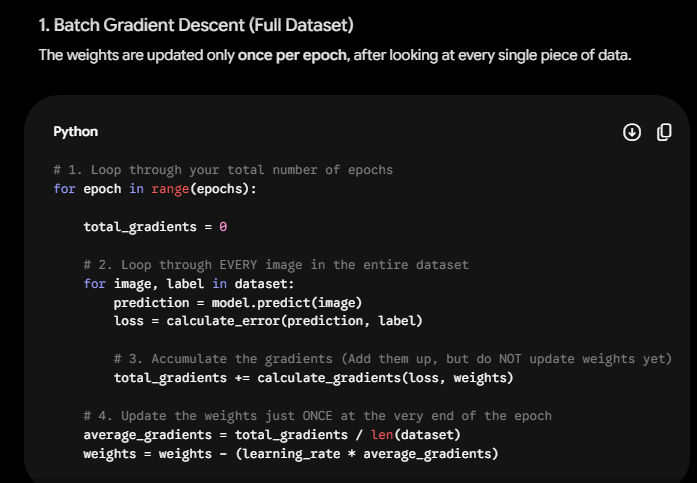


2. **Stochastic Gradient Descent / SGD (The Chaotic Speedster)**
"Stochastic" just means random. In this method, the batch size is exactly 1.

How it works: It looks at Image 1, calculates the error, and immediately updates the weights (takes a step). Then it looks at Image 2, takes a step, etc. If you have 10,000 images, it takes 10,000 steps per epoch.

The Path: Highly erratic. Because it only looks at one image at a time, if it sees a weird outlier image, the hiker will literally step in the wrong direction! The path to the bottom is a wild, jagged zig-zag.

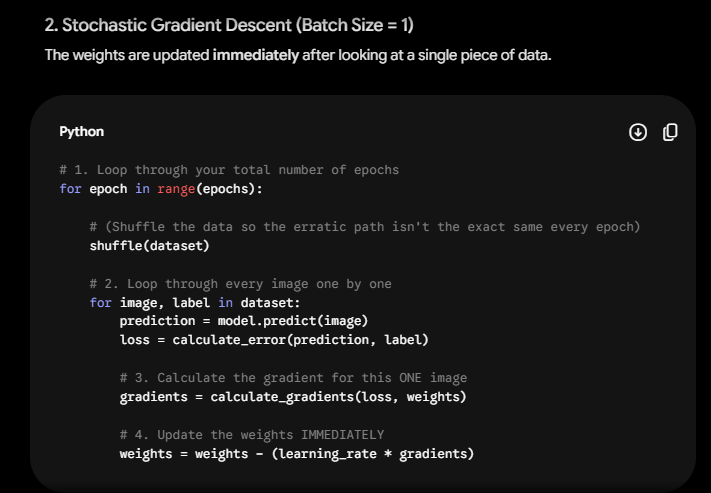



3. **Mini-Batch Gradient Descent (The Industry Standard)**
This is the Goldilocks solution and the method used by every single Deep Learning engineer in the world today.

How it works: You split your dataset into small "chunks" (usually 32, 64, or 128 images). The model looks at 32 images at once, averages their error, and takes a step.

The Path: It has slight wiggles (because 32 images aren't a perfect representation of the whole dataset), but it generally moves smoothly toward the center.

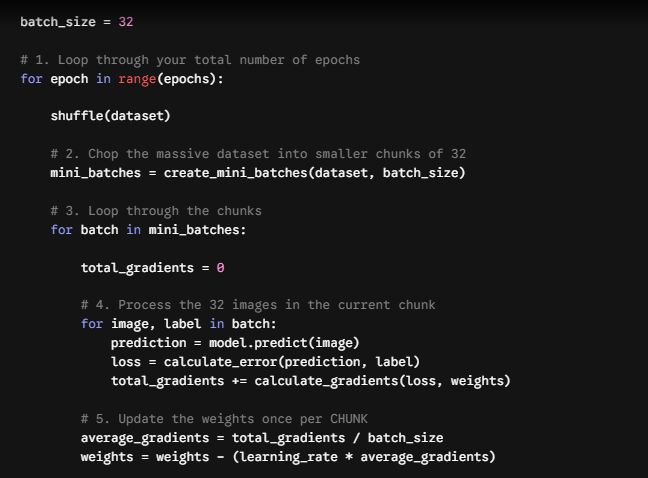

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

In [3]:
df = pd.read_csv('Social_Network_Ads.csv') 

In [4]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [12]:
X = df.drop(columns=["User ID","Purchased","Gender"])
y = df[["Purchased"]]
X

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [13]:
y

,Purchased
0,0
1,0
2,0
3,0
4,0
...,...
395,1
396,1
397,1
398,0


In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [15]:
X_scaled.shape

(400, 2)

In Tensorflow

In [16]:
import tensorflow as tf

C:\Users\Hp\AppData\Roaming\Python\Python311\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [17]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10,activation='relu',input_dim=2),
    tf.keras.layers.Dense(10,activation='relu'),
    tf.keras.layers.Dense(1),
])

C:\Users\Hp\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

Stochastic Gradient Descent (Batch Size = 1)
Time:101.2761435508728

In [24]:
model.compile(loss="binary_crossentropy",metrics=['accuracy'])
start = time.time()
history = model.fit(X_scaled,y,epochs=150,batch_size=1,validation_split=0.2)
# history = model.fit(X_scaled,y,epochs=150,batch_size=400,validation_split=0.2)
print(time.time() - start)

Epoch 1/150


320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8687 - loss: 2.0620 - val_accuracy: 0.6250 - val_loss: 6.0517
Epoch 2/150
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8719 - loss: 2.0624 - val_accuracy: 0.6250 - val_loss: 6.0506
Epoch 3/150
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8719 - loss: 2.0632 - val_accuracy: 0.6250 - val_loss: 6.0520
Epoch 4/150
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8719 - loss: 2.0621 - val_accuracy: 0.6250 - val_loss: 6.0522
Epoch 5/150
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8719 - loss: 2.0624 - val_accuracy: 0.6250 - val_loss: 6.0508
Epoch 6/150
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8687 - loss: 2.0230 - val_accuracy: 0.6250 - val_loss: 5.8816
Epoch 7/150
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8719 - loss: 2.0610 - val_accuracy: 0.6250 - val_loss: 6.0501
Epoch 8/150
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8719 - loss: 2.0624 - val_accuracy: 0.6250

Batch Gradient Descent (Full Dataset)
Time:16.55237650871277

In [25]:
model.compile(loss="binary_crossentropy",metrics=['accuracy'])
start = time.time()
history2 = model.fit(X_scaled,y,epochs=150,batch_size=400,validation_split=0.2)
print(time.time() - start)

Epoch 1/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 842ms/step - accuracy: 0.8719 - loss: 2.0606 - val_accuracy: 0.6250 - val_loss: 6.0512
Epoch 2/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.8719 - loss: 2.0611 - val_accuracy: 0.6125 - val_loss: 6.0532
Epoch 3/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.8719 - loss: 2.0605 - val_accuracy: 0.6250 - val_loss: 5.9059
Epoch 4/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.8719 - loss: 2.0604 - val_accuracy: 0.6125 - val_loss: 6.0539
Epoch 5/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.8719 - loss: 2.0604 - val_accuracy: 0.6125 - val_loss: 6.0535
Epoch 6/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.8719 - loss: 2.0604 - val_accuracy: 0.6125 - val_loss: 6.0533
Epoch 7/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.8719 - loss: 2.0603 - val_accuracy: 0.6125 - val_loss: 6.0532
Epoch 8/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.8719 - loss: 2.0603 - val_accuracy: 0.6125 - val_lo

1. Where Batch Gradient Descent is Faster
Batch Gradient Descent (and large Mini-Batch) wins when we measure Hardware Execution Speed.

1.Vectorization (Time per Epoch): GPUs are designed to do thousands of math problems at the exact same time.

2.Stable Gradients: Because Batch calculates the average error of the whole dataset, its mathematical path is a perfectly smooth line.

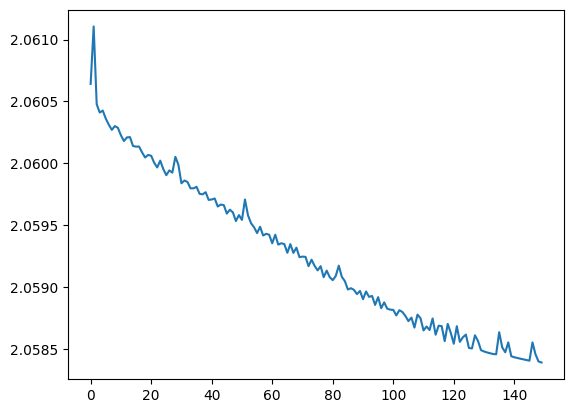

In [27]:
plt.plot(history2.history['loss'])

2. Where Stochastic Gradient Descent (SGD) is Faster
SGD wins when we measure Time to Convergence (how quickly it finds a "good enough" answer).

Weight Updates per Epoch: If you have 10,000 images, Batch Gradient Descent only updates its weights 1 time per epoch. 

SGD updates its weights 10,000 times per epoch. 

Even though SGD is slower in wall-clock time, it will mathematically reach the bottom of the valley in far fewer epochs.

1.Escaping Local Minimums: If the loss landscape has a "fake" valley (a local minimum), a Batch algorithm might get smoothly trapped in it forever.

2.Memory (VRAM): If your dataset is 50 Gigabytes, Batch Gradient Descent will instantly crash your GPU (Speed = 0). SGD requires almost zero memory, meaning it can train infinitely large datasets.

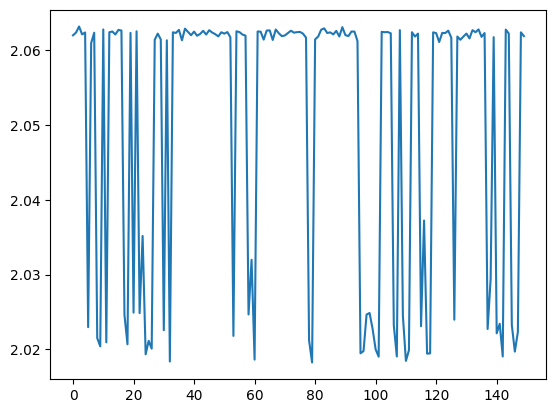

In [28]:
plt.plot(history.history['loss'])

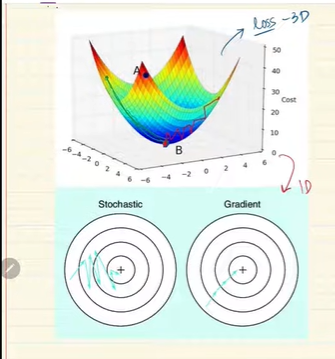